In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 70.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=39c5db8a6d86a1e05d0be91cd0c6aebdbbaeccebfbc6553d9be22dfce88a2e7f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


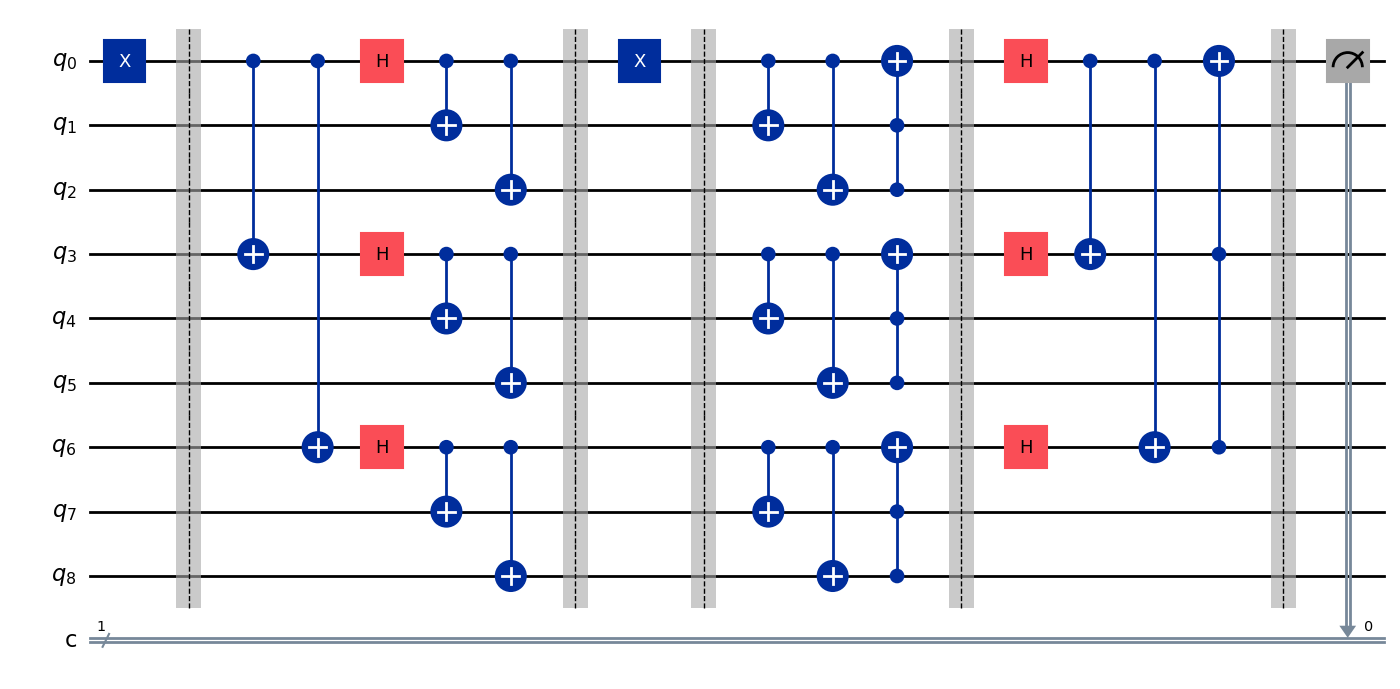

In [8]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor code
shor = QuantumCircuit(9, 1)

# Implement the Shor code and experiment with it, checking that it can correct bit-flip and phase-flip errors.
# You can also try applying some other unitary operator as an error, e.g. H.
# You can even construct a unitary operator from a function (as in Lab 3) and apply it as an error.
# You need more qubits now, so you will also have to change the simulation and measurement code in the next cell.

# Prepare qubit 0 — use x(0) for easy verification
shor.x(0)  # |1> state — easy to verify, change to h(0) for superposition
shor.barrier()

# Phase-flip encoding (outer code)
shor.cx(0, 3)
shor.cx(0, 6)
shor.h(0)
shor.h(3)
shor.h(6)

# Bit-flip encoding (inner code) for each block
shor.cx(0, 1)
shor.cx(0, 2)
shor.cx(3, 4)
shor.cx(3, 5)
shor.cx(6, 7)
shor.cx(6, 8)
shor.barrier()

# Introduce an error — try different errors one at a time
# Bit flip error (correctable)
shor.x(0)

# Phase flip error (correctable)
# shor.z(0)

# Both bit and phase flip (correctable)
# shor.x(0)
# shor.z(0)

# H error (correctable)
# shor.h(0)

shor.barrier()

# Bit-flip correction for each block using Toffoli
shor.cx(0, 1)
shor.cx(0, 2)
shor.ccx(1, 2, 0)

shor.cx(3, 4)
shor.cx(3, 5)
shor.ccx(4, 5, 3)

shor.cx(6, 7)
shor.cx(6, 8)
shor.ccx(7, 8, 6)

shor.barrier()

# Phase-flip correction
shor.h(0)
shor.h(3)
shor.h(6)
shor.cx(0, 3)
shor.cx(0, 6)
shor.ccx(3, 6, 0)

shor.barrier()

# Measure qubit 0
shor.measure(0, 0)
shor.draw("mpl")

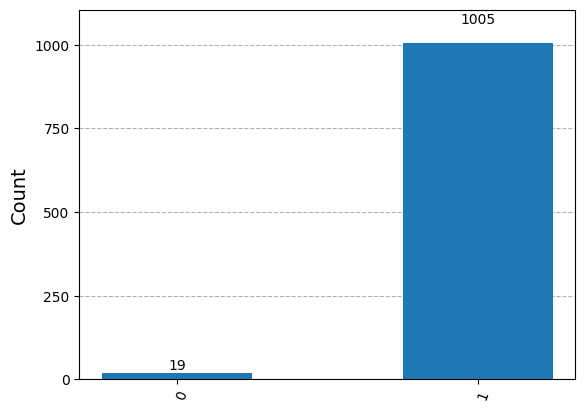

In [9]:
# Simulate and plot results
backend = GenericBackendV2(num_qubits=9, control_flow=True)
compiled = transpile(shor, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts()
plot_histogram(counts)